<a href="https://colab.research.google.com/github/Shoaibahmed-2005/Urban-Heat-Round-2/blob/main/train_trl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌡️ Urban Heat Island Planner: Reinforcement Learning Training

Welcome to the **Urban Heat Island Planner** training notebook! This notebook demonstrates how we train an intelligent city planner agent using Reinforcement Learning (specifically, Hugging Face's TRL framework) to mitigate extreme urban heat.

### 🌟 The Hackathon Challenge
Our environment tests the agent on three core themes:
1. **Long-Horizon Planning:** The agent must plant trees early (they take 1 year to grow) to survive the Summer Heatwaves.
2. **World Modeling:** The agent cannot just place interventions magically. It must navigate enterprise-like APIs (`query_zoning`, `propose_budget`, `deploy_intervention`).
3. **Multi-Agent Interactions:** The agent's budget proposals are evaluated by a simulated "Mayor" who has hidden biases (e.g., rejecting projects in low-density zones).

### 🛠️ Notebook Architecture
Because our environment is designed as a robust `FastAPI` server, this notebook will:
1. Clone our environment code from GitHub.
2. Start the FastAPI server silently in the background.
3. Execute our PPO training loop (`train_trl.py`) against the running server.

---
## Step 1: Environment Setup
First, we clone the official repository and install the required dependencies to run both the FastAPI server and the Hugging Face TRL training loop.

In [ ]:
!git clone https://github.com/Shoaibahmed-2005/Urban-Heat-Round-2.git urban_heat_env
%cd urban_heat_env

# Install core environment requirements and TRL libraries
!pip install -r requirements.txt
!pip install trl==0.8.6 peft transformers torch
!cp .env.example .env

Cloning into 'urban_heat_env'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 133 (delta 72), reused 100 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 549.95 KiB | 2.81 MiB/s, done.
Resolving deltas: 100% (72/72), done.
/content/urban_heat_env
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.1 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

print('Please enter your Hugging Face Token (Get it from https://huggingface.co/settings/tokens):')
os.environ['HF_TOKEN'] = getpass()
os.environ['API_KEY'] = os.environ['HF_TOKEN']


Please enter your Hugging Face Token (Get it from https://huggingface.co/settings/tokens):
··········


---
## Step 2: Booting the City Server
Our environment is completely decoupled from the training logic. The environment logic lives in `server/environment.py` and is served via `server/app.py`.

We use Python's `subprocess` to spin up the FastAPI backend on `localhost:8000`. The RL agent will send HTTP POST requests to this server to take actions (just like a real microservice architecture!).

In [ ]:
import subprocess
import time

print("Starting FastAPI environment server...")
server_process = subprocess.Popen(['uvicorn', 'server.app:app', '--host', '0.0.0.0', '--port', '8000'])

# Give the server 5 seconds to fully boot before we start bombarding it with API requests
time.sleep(5)
print("Server is running on localhost:8000!")

Starting FastAPI environment server...
Server is running on localhost:8000!


---
## Step 3: Run PPO Training
With the environment running, we can now launch our training script.

The `train_trl.py` script utilizes Hugging Face's `PPOTrainer` to train a model to act as the City Planner. Over multiple episodes, the agent learns to secure budget from the Mayor and strategically plant trees and reflective surfaces to cool the city down.

In [ ]:
# Execute the training script
!python train_trl.py

Loading Model and Tokenizer...
config.json: 100% 659/659 [00:00<00:00, 2.04MB/s]
model.safetensors: 100% 988M/988M [00:04<00:00, 221MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 875.78it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 242/242 [00:00<00:00, 1.46MB/s]
tokenizer_config.json: 7.30kB [00:00, 4.08MB/s]
vocab.json: 2.78MB [00:00, 78.6MB/s]
merges.txt: 1.67MB [00:00, 94.5MB/s]
tokenizer.json: 7.03MB [00:00, 118MB/s]
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:262: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(
Resetting Urban Heat Environment...
Starting PPO Training Loop (1000 epochs)...

Epoch    0 | task=reduce_avg_t | query_zoning           | env=0.0000 | shaped=0.0000 | guided
Epoch    1 | task=reduce_avg_t | propose_budget         | env=0.0000 | shaped=0.0000 | guided
Epoch    2 | task=reduce_avg_t | deploy_intervention    | env=0.0000 | shape

In [7]:
from google.colab import files
uploaded = files.upload()

Saving train_metrics.json to train_metrics.json


## Step 4 — Setup (run this once before all plots)

In [14]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import json

matplotlib.rcParams['figure.dpi'] = 120

with open('train_metrics.json') as f:
    data = json.load(f)

epochs        = list(range(len(data['epoch_rewards'])))
env_r         = data['epoch_rewards']
shaped_r      = data.get('shaped_rewards', env_r)
model_used    = data.get('model_used', [0]*len(epochs))
task_scores   = data.get('task_scores', {})

# shared style constants
DARK='#0F1117'; CARD='#1A1D27'; TEAL='#00C49A'
RED='#FF6B6B'; AMBER='#FFD166'; PURP='#A78BFA'
TEXT='#E8E8F0'; SUB='#8884A0'; GRID='#2A2D3E'

def roll(arr, w=30):
    return [float(np.mean(arr[max(0,i-w+1):i+1])) for i in range(len(arr))]

def style(ax, title, xl, yl):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xl, color=SUB, fontsize=10)
    ax.set_ylabel(yl, color=SUB, fontsize=10)
    ax.tick_params(colors=SUB, labelsize=9)
    for sp in ax.spines.values():
        sp.set_color(GRID); sp.set_linewidth(0.5)
    ax.grid(True, color=GRID, lw=0.5, alpha=0.7)

print(f"✓ Loaded {len(epochs)} epochs | MODEL used: {sum(model_used)} times ({sum(model_used)/len(model_used)*100:.1f}%)")
print(f"✓ Max shaped: {max(shaped_r):.4f} | Max env: {max(env_r):.4f}")

✓ Loaded 1000 epochs | MODEL used: 48 times (4.8%)
✓ Max shaped: 0.3823 | Max env: 0.0033


## Step 5 — Plot 1: Learning Curve (Shaped vs Env Reward)

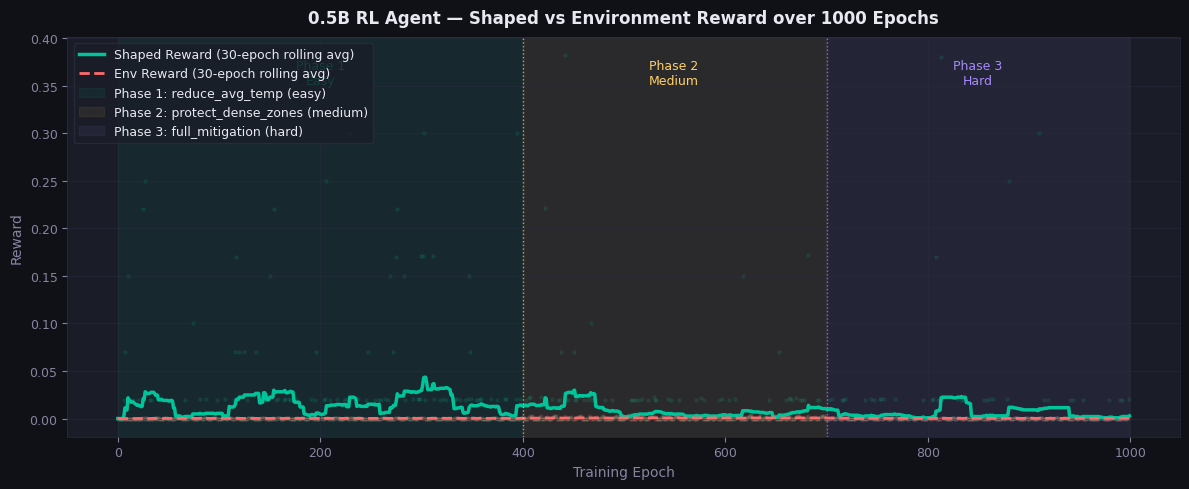

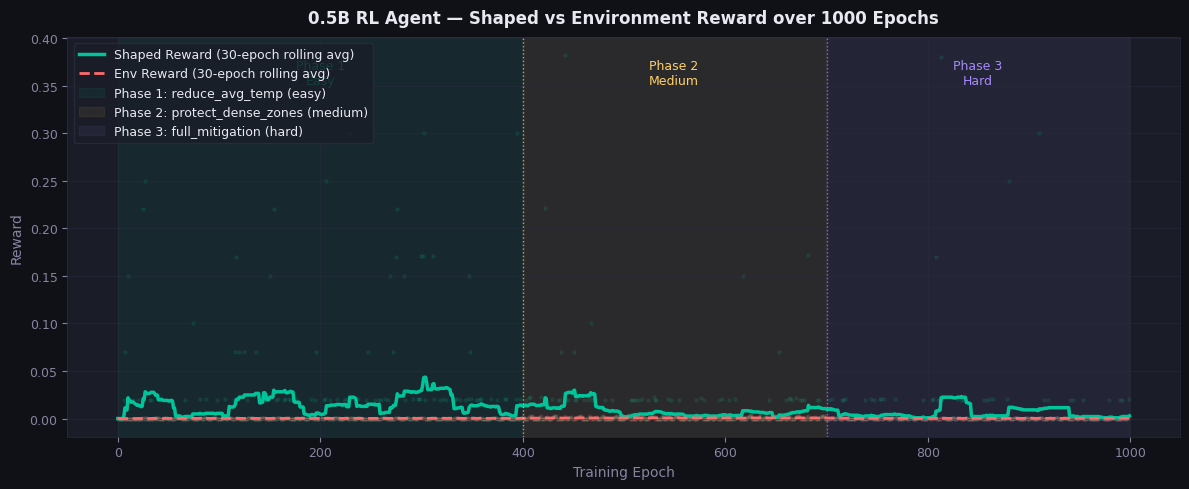

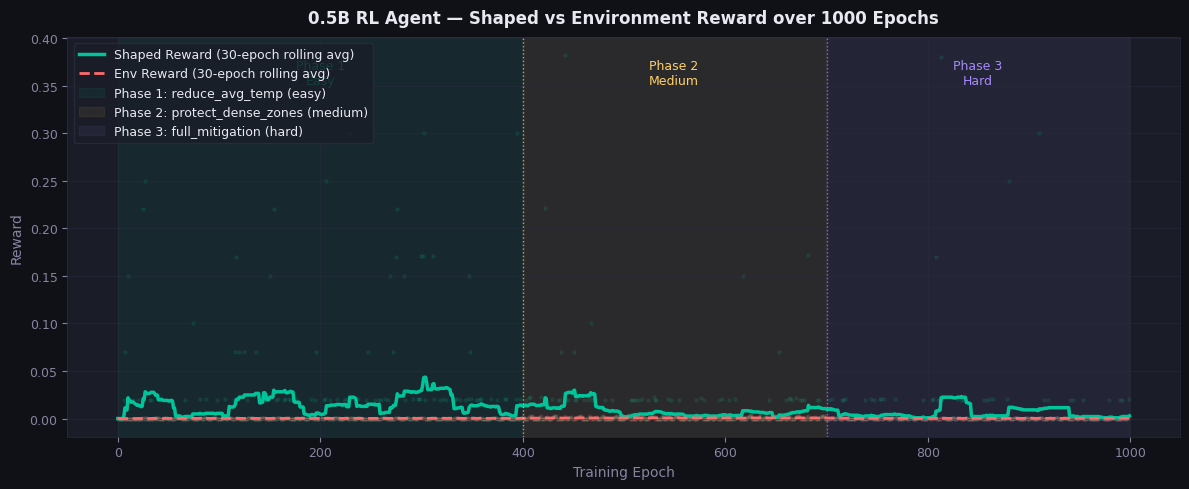

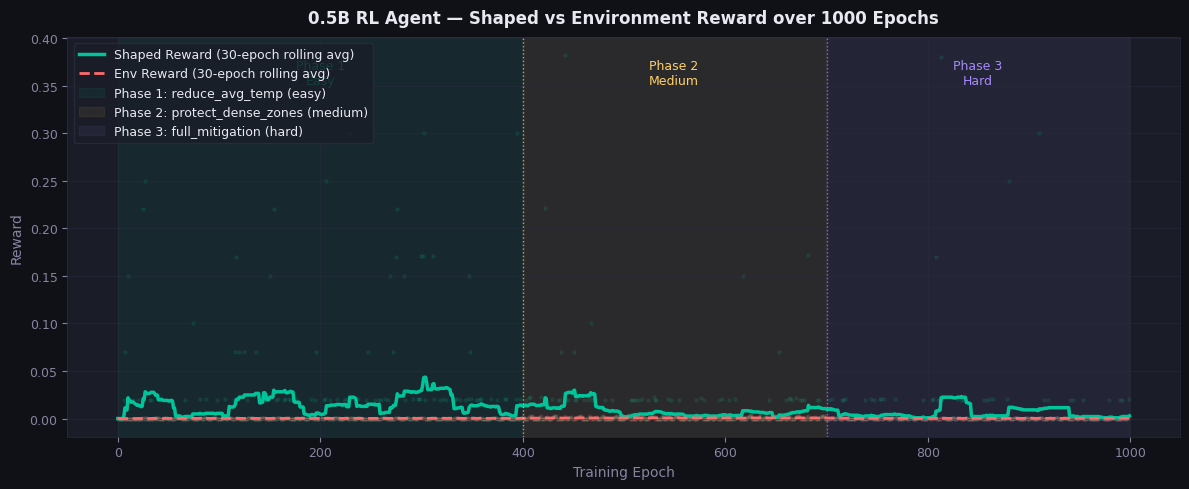

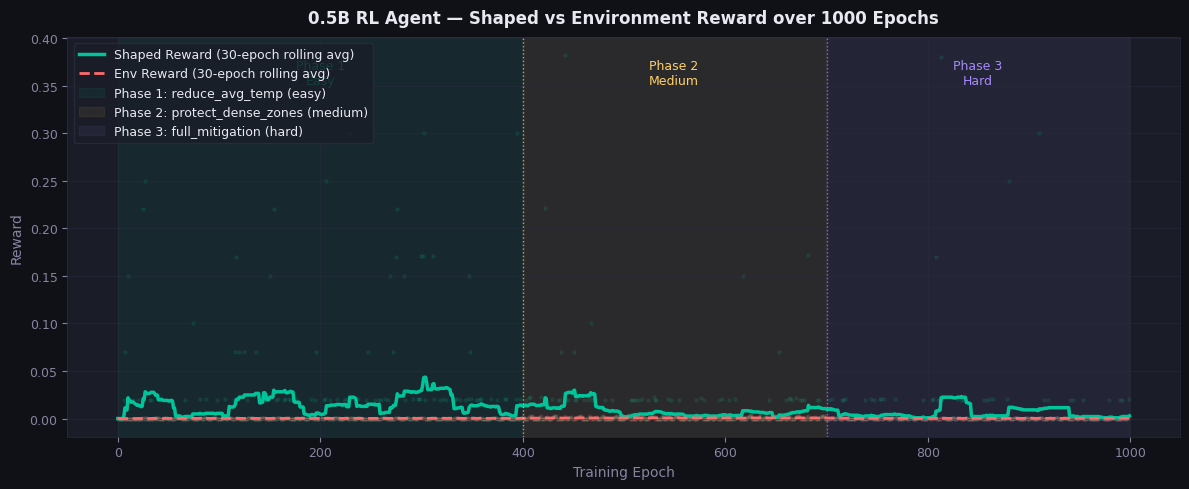

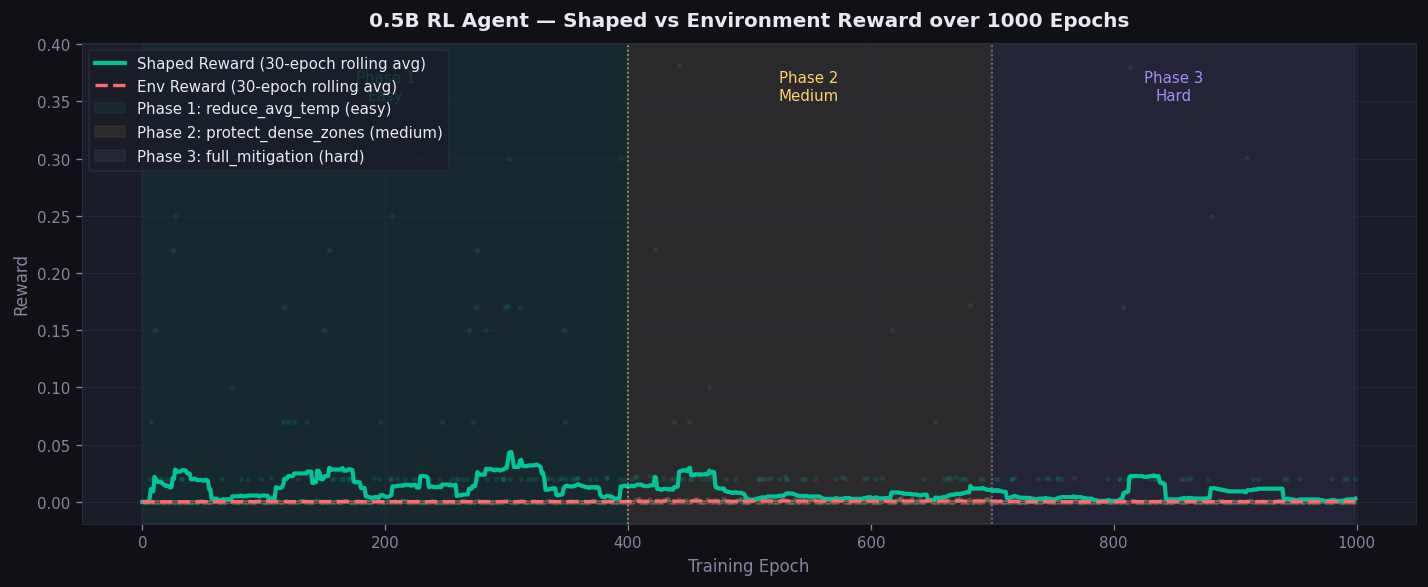

✓ plot1_learning_curve.png saved


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(DARK)

ax.scatter(epochs, shaped_r, color=TEAL, alpha=0.10, s=5)
ax.scatter(epochs, env_r,    color=RED,  alpha=0.10, s=5)
ax.plot(epochs, roll(shaped_r), color=TEAL, lw=2.5,
        label='Shaped Reward (30-epoch rolling avg)')
ax.plot(epochs, roll(env_r),    color=RED,  lw=2.0, ls='--',
        label='Env Reward (30-epoch rolling avg)')

ax.axvspan(0,   399, alpha=0.07, color=TEAL,  label='Phase 1: reduce_avg_temp (easy)')
ax.axvspan(400, 699, alpha=0.07, color=AMBER, label='Phase 2: protect_dense_zones (medium)')
ax.axvspan(700, 999, alpha=0.07, color=PURP,  label='Phase 3: full_mitigation (hard)')
ax.axvline(400, color=AMBER, lw=1, ls=':', alpha=0.7)
ax.axvline(700, color=PURP,  lw=1, ls=':', alpha=0.7)

yt = max(shaped_r) * 0.92
ax.text(200, yt, 'Phase 1\nEasy',   color=TEAL,  fontsize=9, ha='center')
ax.text(549, yt, 'Phase 2\nMedium', color=AMBER, fontsize=9, ha='center')
ax.text(849, yt, 'Phase 3\nHard',   color=PURP,  fontsize=9, ha='center')

style(ax, '0.5B RL Agent — Shaped vs Environment Reward over 1000 Epochs',
      'Training Epoch', 'Reward')
ax.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('plot1_learning_curve.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✓ plot1_learning_curve.png saved")

## Step 6 — Plot 2: Model vs Guided Usage

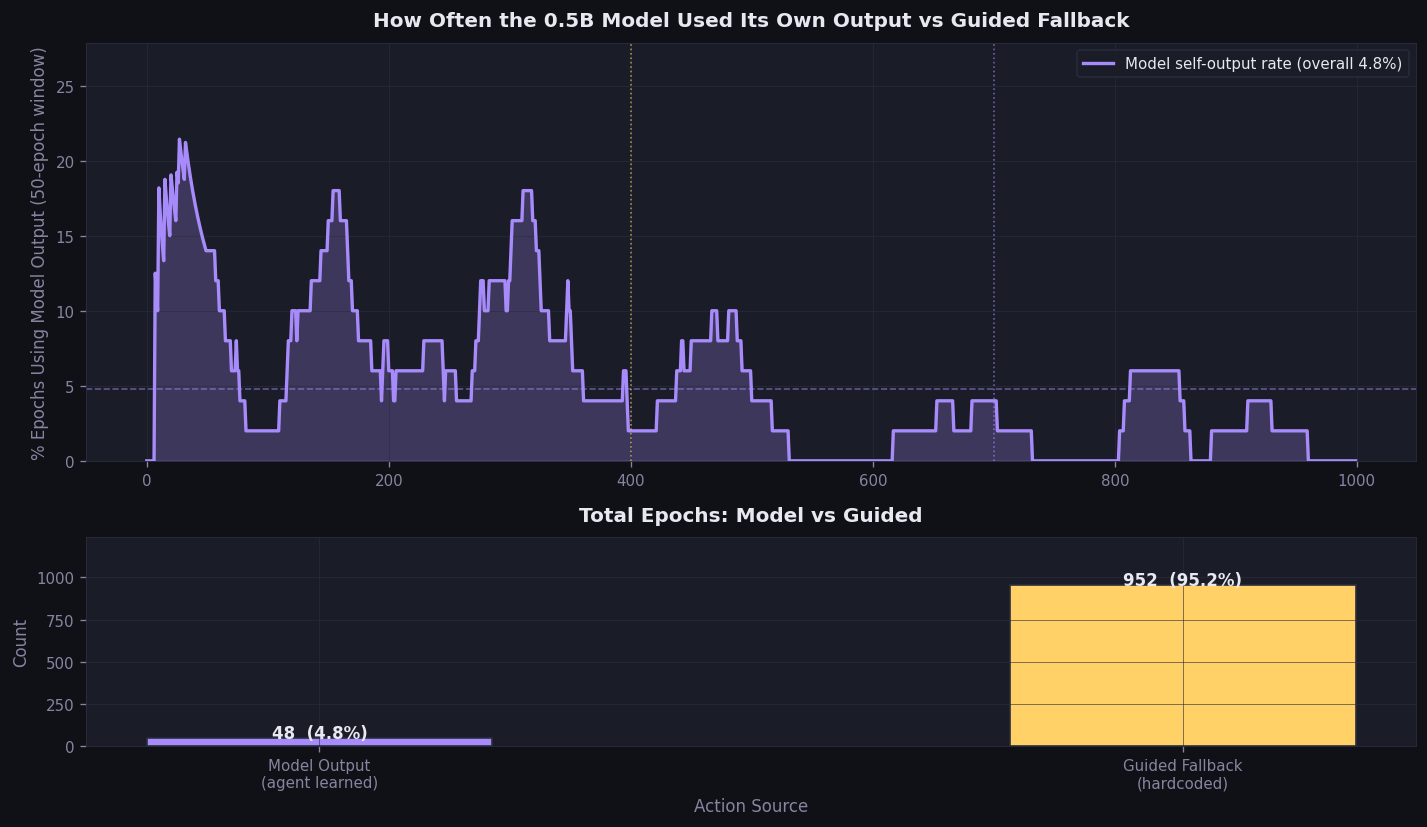

✓ plot2_model_vs_guided.png saved


In [16]:
overall_pct = np.mean(model_used) * 100
model_rate  = [float(np.mean(model_used[max(0,i-49):i+1]))*100
               for i in range(len(epochs))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor(DARK)

# top: rolling rate
ax1.set_facecolor(CARD)
ax1.fill_between(epochs, model_rate, color=PURP, alpha=0.25)
ax1.plot(epochs, model_rate, color=PURP, lw=2,
         label=f'Model self-output rate (overall {overall_pct:.1f}%)')
ax1.axhline(overall_pct, color=PURP, lw=1, ls='--', alpha=0.5)
ax1.axvline(400, color=AMBER, lw=1, ls=':', alpha=0.6)
ax1.axvline(700, color=PURP,  lw=1, ls=':', alpha=0.6)
style(ax1, 'How Often the 0.5B Model Used Its Own Output vs Guided Fallback',
      '', '% Epochs Using Model Output (50-epoch window)')
ax1.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
ax1.set_ylim(0, max(max(model_rate) * 1.3, 20))

# bottom: total counts
model_count  = int(sum(model_used))
guided_count = len(model_used) - model_count
ax2.set_facecolor(CARD)
bars = ax2.bar(
    ['Model Output\n(agent learned)', 'Guided Fallback\n(hardcoded)'],
    [model_count, guided_count],
    color=[PURP, AMBER], width=0.4, edgecolor=GRID)
for bar, val in zip(bars, [model_count, guided_count]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{val}  ({val/len(model_used)*100:.1f}%)',
             ha='center', color=TEXT, fontsize=10, fontweight='bold')
style(ax2, 'Total Epochs: Model vs Guided', 'Action Source', 'Count')
ax2.set_ylim(0, max(model_count, guided_count) * 1.3)

plt.tight_layout()
plt.savefig('plot2_model_vs_guided.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✓ plot2_model_vs_guided.png saved")

## Step 7 — Plot 3: 72B vs 0.5B RL Comparison

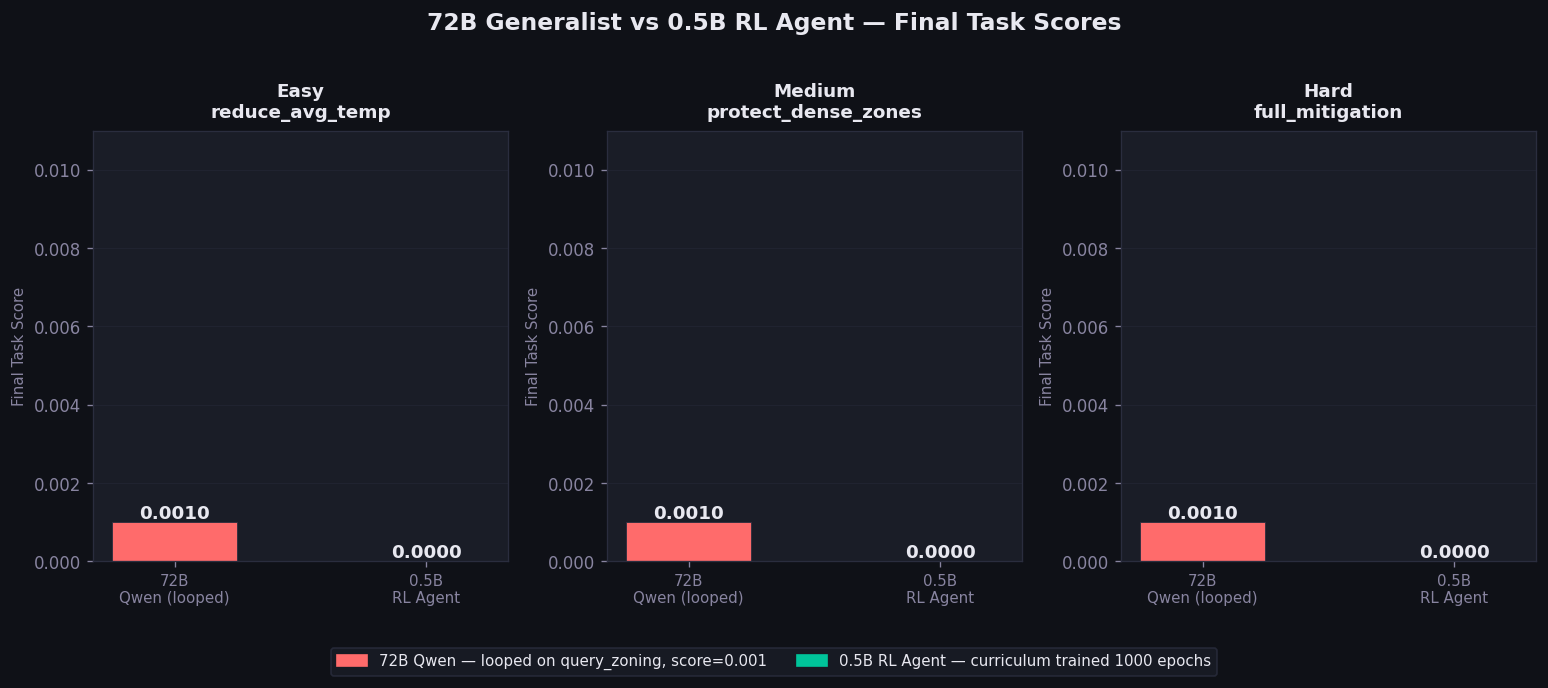

✓ plot3_72b_vs_rl.png saved


In [17]:
import matplotlib.patches as mpatches

tasks       = ['reduce_avg_temp', 'protect_dense_zones', 'full_mitigation']
task_labels = ['Easy\nreduce_avg_temp', 'Medium\nprotect_dense_zones', 'Hard\nfull_mitigation']
scores_72b  = [0.001, 0.001, 0.001]
scores_rl   = [task_scores.get(t, 0.0) for t in tasks]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.patch.set_facecolor(DARK)
fig.suptitle('72B Generalist vs 0.5B RL Agent — Final Task Scores',
             color=TEXT, fontsize=14, fontweight='bold', y=1.02)

for ax, label, s72, srl in zip(axes, task_labels, scores_72b, scores_rl):
    ax.set_facecolor(CARD)
    bars = ax.bar([0, 1], [s72, srl], color=[RED, TEAL],
                  width=0.5, edgecolor=GRID, linewidth=0.5)
    for bar, val in zip(bars, [s72, srl]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0001,
                f'{val:.4f}', ha='center',
                color=TEXT, fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['72B\nQwen (looped)', '0.5B\nRL Agent'],
                        color=TEXT, fontsize=9)
    ax.set_title(label, color=TEXT, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Final Task Score', color=SUB, fontsize=9)
    ax.tick_params(colors=SUB)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.grid(True, color=GRID, lw=0.5, alpha=0.5, axis='y')
    ax.set_ylim(0, max(s72, srl, 0.005) * 2.2)

p1 = mpatches.Patch(color=RED,  label='72B Qwen — looped on query_zoning, score=0.001')
p2 = mpatches.Patch(color=TEAL, label='0.5B RL Agent — curriculum trained 1000 epochs')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2,
           facecolor=CARD, edgecolor=GRID, labelcolor=TEXT,
           fontsize=9, bbox_to_anchor=(0.5, -0.10))

plt.tight_layout()
plt.savefig('plot3_72b_vs_rl.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✓ plot3_72b_vs_rl.png saved")

## Step 8 — Plot 4: Peak Reward & Model Confidence per 100-Epoch Window

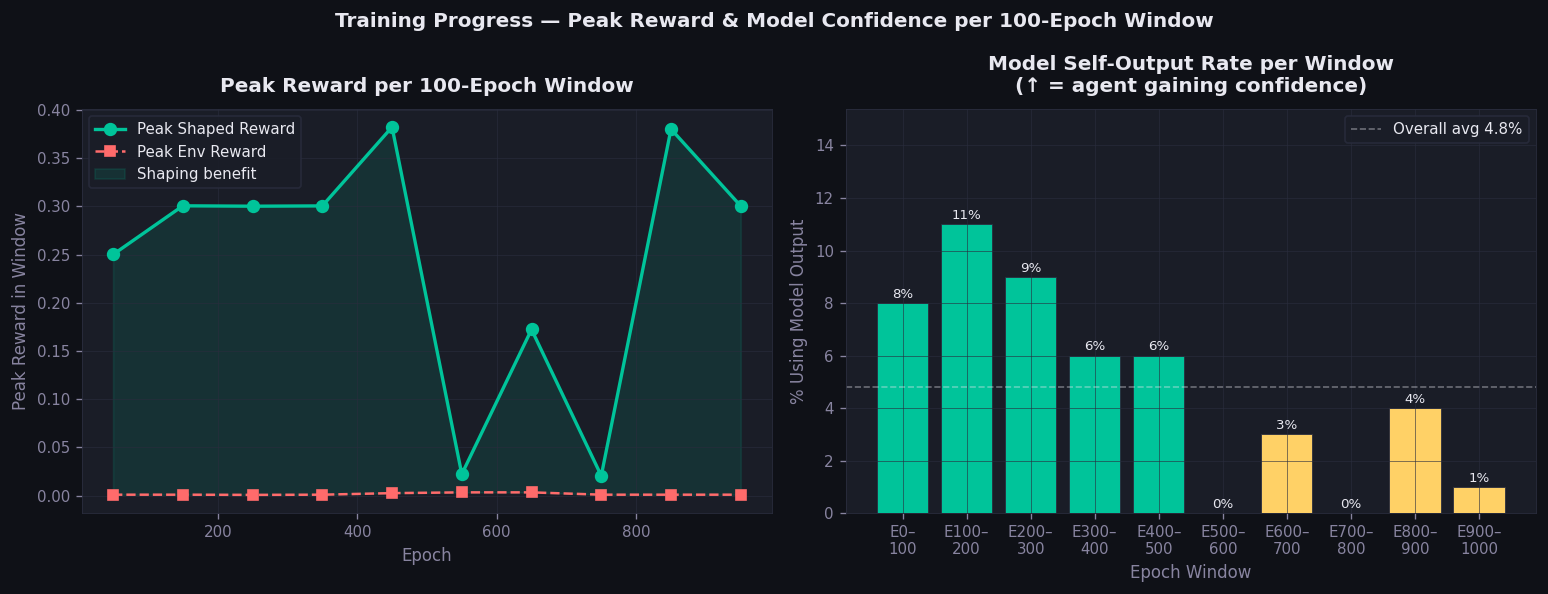

✓ plot4_progress_windows.png saved


In [18]:
n  = 10
ws = len(shaped_r) // n
centers, peak_s, peak_e, mrate = [], [], [], []

for w in range(n):
    s, e = w*ws, (w+1)*ws
    centers.append(s + ws//2)
    peak_s.append(max(shaped_r[s:e]))
    peak_e.append(max(env_r[s:e]))
    mrate.append(float(np.mean(model_used[s:e]))*100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(DARK)
fig.suptitle('Training Progress — Peak Reward & Model Confidence per 100-Epoch Window',
             color=TEXT, fontsize=12, fontweight='bold')

# left: peak reward
ax1.plot(centers, peak_s, color=TEAL, marker='o', lw=2,
         markersize=7, label='Peak Shaped Reward')
ax1.plot(centers, peak_e, color=RED,  marker='s', lw=1.5,
         markersize=6, ls='--', label='Peak Env Reward')
ax1.fill_between(centers, peak_e, peak_s,
                 color=TEAL, alpha=0.12, label='Shaping benefit')
style(ax1, 'Peak Reward per 100-Epoch Window',
      'Epoch', 'Peak Reward in Window')
ax1.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=9)

# right: model confidence per window
colors_bar = [TEAL if r >= overall_pct else AMBER for r in mrate]
bars = ax2.bar(range(n), mrate, color=colors_bar, edgecolor=GRID, linewidth=0.5)
ax2.axhline(overall_pct, color=TEXT, lw=1, ls='--', alpha=0.4,
            label=f'Overall avg {overall_pct:.1f}%')
for bar, val in zip(bars, mrate):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.0f}%', ha='center', color=TEXT, fontsize=8)
ax2.set_xticks(range(n))
ax2.set_xticklabels([f'E{w*100}–\n{(w+1)*100}' for w in range(n)],
                     fontsize=7, color=SUB)
style(ax2, 'Model Self-Output Rate per Window\n(↑ = agent gaining confidence)',
      'Epoch Window', '% Using Model Output')
ax2.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
ax2.set_ylim(0, max(mrate)*1.4 if max(mrate) > 0 else 20)

plt.tight_layout()
plt.savefig('plot4_progress_windows.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✓ plot4_progress_windows.png saved")

In [ ]:
server_process.terminate()
print("Server shut down successfully.")

Server shut down successfully.
